# Dataset spatial operations

`pyramids` wraps GDAL so that common raster transformations become a single method call on a `Dataset`.
In this tutorial you load a digital-elevation model (DEM) of the Rhine river basin and walk through the
three spatial operations you reach for most often: **resampling** to a coarser grid, **reprojecting** to
a different coordinate reference system, and **cropping** one raster to the extent of another. Along the
way you will see how each operation changes the grid's cell size, dimensions, and CRS.

The spatial toolkit splits into two families: methods that **transform the grid itself** (live on
`ds.spatial`) and methods that **sample or summarise values** at points and zones (live on `ds.analysis`):

```mermaid
flowchart TB
    DS(("Dataset<br/>spatial operations"))
    DS --> T["<b>transform the grid</b> · ds.spatial<br/>resample · to_crs · align · crop"]
    DS --> S["<b>sample & summarise</b> · ds.analysis<br/>sample · extract · overlay · footprint"]
```

This tutorial focuses on the grid transforms — resampling, reprojecting, and cropping.

## Load the data

We import the `Dataset` class — the entry point for every raster in pyramids — and point at a GeoTIFF DEM
of the Rhine basin. The path is relative to this notebook.

In [1]:
# NBVAL_IGNORE_OUTPUT
from pyramids.dataset import Dataset

%matplotlib inline

path = "../../../examples/data/dem/DEM5km_Rhine_burned_fill.tif"

`Dataset.read_file` opens the GeoTIFF through GDAL and returns a `Dataset` object; it references the file
lazily rather than pulling all the pixels into memory.

In [2]:
dataset = Dataset.read_file(path)

Printing a `Dataset` shows a summary of its geospatial metadata — corner, cell size, dimensions, EPSG
code, band information, and no-data value — a quick way to sanity-check what you just loaded.

In [3]:
print(dataset)


            Top Left Corner: (32239263.70388, 5756081.42235)
            Cell size: 5000.0
            Dimension: 125 * 93
            EPSG: 4647
            Number of Bands: 1
            Band names: ['Band_1']
            Band colors: {0: 'gray_index'}
            Band units: ['']
            Scale: [1.0]
            Offset: [0]
            Mask: -3.4028234663852886e+38
            Data type: float32
            File: ../../../examples/data/dem/DEM5km_Rhine_burned_fill.tif
        


`Dataset.plot` renders one band as a map through cleopatra and returns the glyph object. A few options
worth knowing:

| parameter | meaning | typical value |
| --- | --- | --- |
| `band` | which band to draw (0-based) | `0` |
| `vmin` / `vmax` | clip the colour scale to this range | `0`, `30` |
| `title` | figure title | any string |
| `cbar_label` | colour-bar label | e.g. `"Elevation(m)"` |

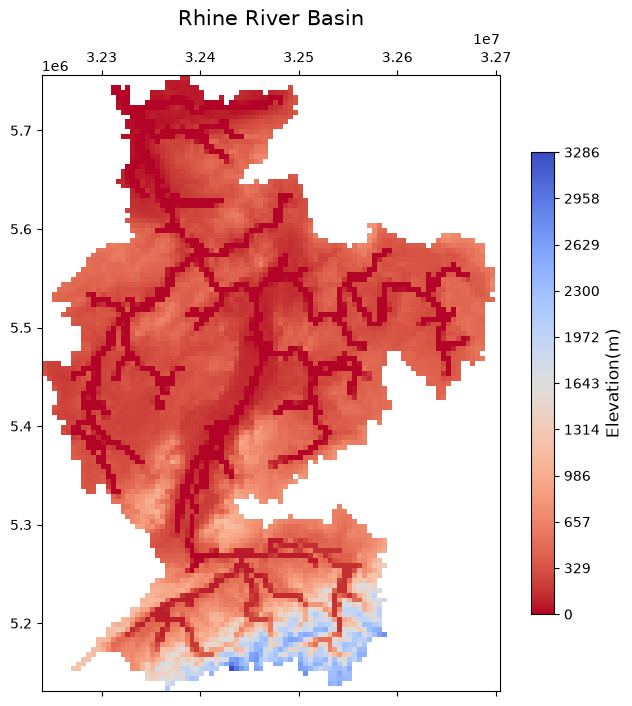

In [4]:
dataset.plot(vmin=0, title="Rhine River Basin", cbar_label="Elevation(m)")

The DEM shows the Rhine basin: higher elevations (bright) toward the mountainous south, descending to the
low-lying north-west. This is the grid that every operation below will transform.

## Resampling

Resampling changes the pixel size (spatial resolution) of a raster, recomputing its values onto a new
grid. Coarser cells shrink the array and smooth out detail; finer cells enlarge it. Before resampling,
let's confirm the raster's current cell size.

In [5]:
print(f"Cell size: {dataset.cell_size}")

Cell size: 5000.0


`resample` recomputes the raster onto a new grid at the requested cell size and returns a new `Dataset`.

| parameter | meaning | typical value |
| --- | --- | --- |
| `cell_size` | target pixel size in the raster's CRS units | `8000` (metres) |
| `method` | interpolation used to fill the new cells | `"bilinear"`, `"nearest"`, `"cubic"` |

Because we move from 5 km to 8 km cells, the output array is smaller and its detail is smoothed.

In [6]:
dataset_8km = dataset.resample(cell_size=8000, method="bilinear")

Plot the resampled DEM to see the effect of the coarser grid.

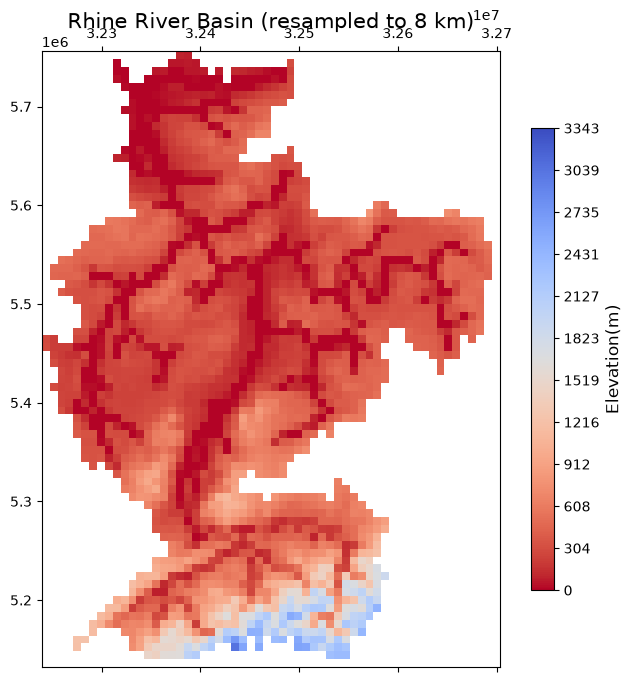

In [7]:
dataset_8km.plot(
    vmin=0, title="Rhine River Basin (resampled to 8 km)", cbar_label="Elevation(m)"
)

Same basin, blockier pixels: each 8 km cell now aggregates an area the old 5 km cells resolved more
finely. The overall elevation pattern is preserved while local detail is lost.

## Reprojecting

Reprojection re-expresses the raster in a different coordinate reference system (CRS). The source DEM is
in a projected metric CRS (EPSG:4647, ETRS89 / UTM zone 32N); we will convert it to geographic lon/lat
degrees (EPSG:4326, WGS 84). First inspect the current CRS and dimensions.

In [8]:
print(f"EPSG: {dataset.epsg}")
print(f"Coordinate reference system: {dataset.crs}")
print(f"Dataset dimensions: {dataset.shape}")

EPSG: 4647
Coordinate reference system: PROJCS["ETRS89 / UTM zone 32N (zE-N)",GEOGCS["ETRS89",DATUM["European_Terrestrial_Reference_System_1989",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6258"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4258"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",9],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",32500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","4647"]]
Dataset dimensions: (1, 125, 93)


`to_crs` warps the grid into the target EPSG code and returns a brand-new `Dataset`. Because degrees and
metres are different units, the cell size and dimensions change as part of the reprojection.

In [9]:
reprojected_dataset = dataset.to_crs(4326)

Print the reprojected dataset. Note the EPSG is now 4326, the corner is expressed in degrees, and the
cell size is a fraction of a degree.

In [10]:
print(reprojected_dataset)


            Top Left Corner: (5.210230290109742, 51.9554111793825)
            Cell size: 0.05475332958287695
            Dimension: 104 * 123
            EPSG: 4326
            Number of Bands: 1
            Band names: ['Band_1']
            Band colors: {0: 'gray_index'}
            Band units: ['']
            Scale: [1.0]
            Offset: [0.0]
            Mask: -3.4028234663852886e+38
            Data type: float32
            File: 
        


Plot the reprojected DEM.

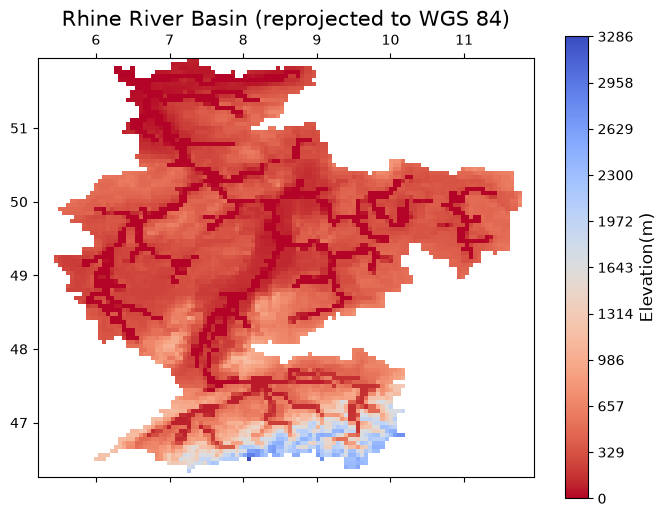

In [11]:
reprojected_dataset.plot(
    vmin=0, title="Rhine River Basin (reprojected to WGS 84)", cbar_label="Elevation(m)"
)

The map now carries lon/lat degree axes instead of metres, and the basin is subtly stretched relative to
the UTM version — that distortion is exactly the warp from a projected grid to a geographic one.

## Cropping to another raster

Cropping (clipping) trims a raster down to the extent of a second dataset — ideal for cutting a large
product to a study area. Here we take a Europe-wide precipitation raster and clip it to the Rhine DEM.
Both rasters must share a CRS before cropping, so we reproject the precipitation raster first. Let's load
it.

In [12]:
path = "../../../examples/data/geotiff/noah-precipitation-1979-europe.tif"
meteo_data = Dataset.read_file(path)

Print its metadata: it is a 4-band daily-precipitation raster covering Europe at 0.5° resolution in
WGS 84 (each band is one day).

In [13]:
print(meteo_data)


            Top Left Corner: (-5.0, 55.0)
            Cell size: 0.5
            Dimension: 25 * 40
            EPSG: 4326
            Number of Bands: 4
            Band names: ['Band_1', 'Band_2', 'Band_3', 'Band_4']
            Band colors: {0: 'gray_index', 1: 'undefined', 2: 'undefined', 3: 'undefined'}
            Band units: ['', '', '', '']
            Scale: [1.0, 1.0, 1.0, 1.0]
            Offset: [0, 0, 0, 0]
            Mask: -9.969209968386869e+36
            Data type: float32
            File: ../../../examples/data/geotiff/noah-precipitation-1979-europe.tif
        


Plot band 0 (the first day) to see the full European extent before cropping.

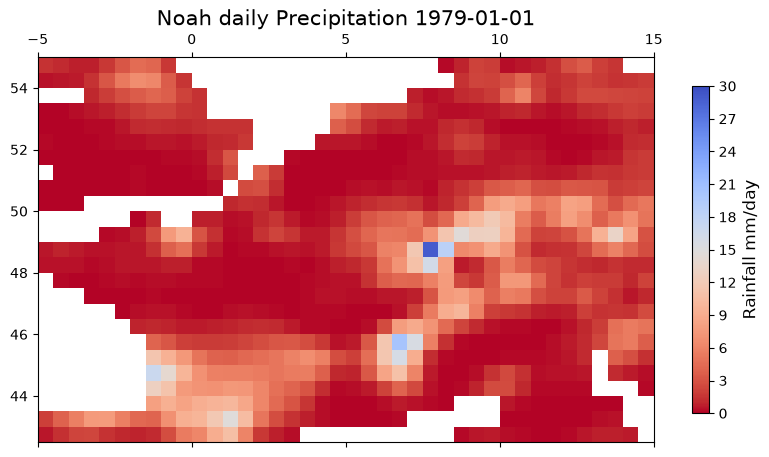

In [14]:
array_glyph = meteo_data.plot(
    band=0,
    figsize=(10, 5),
    title="Noah daily Precipitation 1979-01-01",
    cbar_label="Rainfall mm/day",
    vmax=30,
    cbar_length=0.85,
)

Rainfall covers the whole continent; the Rhine basin is just a small window inside this field.

To crop against the DEM the two rasters must share a CRS, so reproject the precipitation raster from
WGS 84 into the DEM's UTM CRS (EPSG:4647).

In [15]:
meteo_data_r = meteo_data.to_crs(4647)

Plot the reprojected precipitation to confirm it is now on the same metric CRS as the DEM.

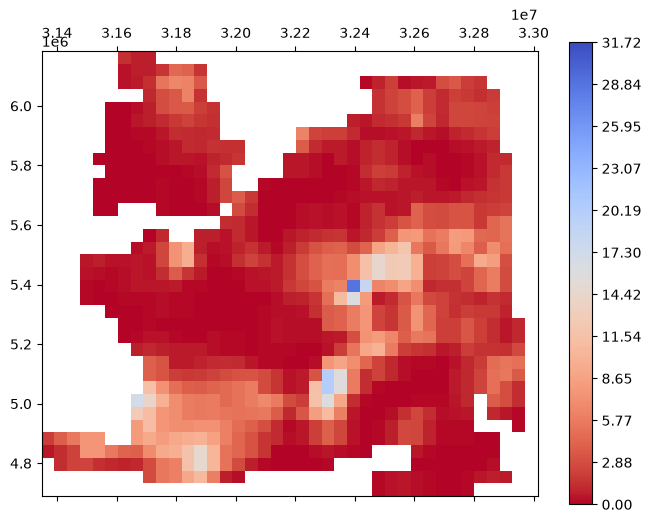

In [16]:
meteo_data_r.plot(band=0)

Same rainfall field, now on a UTM grid with axes in metres — matching the DEM's CRS.

`crop` clips the precipitation raster to the DEM's bounding box, keeping only the cells that overlap the
Rhine basin.

In [17]:
rhine_meteo_data = meteo_data_r.crop(dataset)

Plot the cropped result.

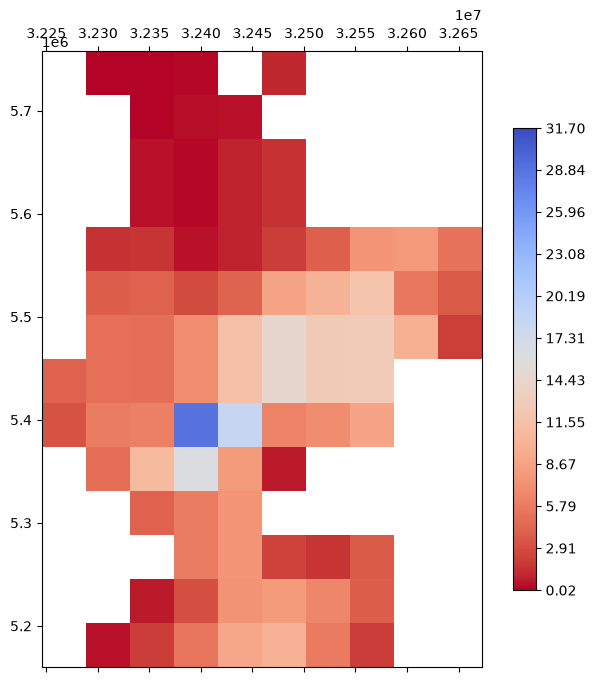

In [18]:
rhine_meteo_data.plot(band=0)

Only the rainfall cells over the Rhine basin remain — the raster has been reduced to the study area.

Finally, echo the cropped dataset's full GDAL description to confirm its reduced size (10 × 14 cells) and
its CRS.

In [19]:
rhine_meteo_data

Driver: MEM/In Memory raster, vector and multidimensional raster
Files: none associated
Size is 10, 14
Coordinate System is:
PROJCRS["ETRS89 / UTM zone 32N (zE-N)",
    BASEGEOGCRS["ETRS89",
        DATUM["European Terrestrial Reference System 1989",
            ELLIPSOID["GRS 1980",6378137,298.257222101,
                LENGTHUNIT["metre",1]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["degree",0.0174532925199433]],
        ID["EPSG",4258]],
    CONVERSION["unnamed",
        METHOD["Transverse Mercator",
            ID["EPSG",9807]],
        PARAMETER["Latitude of natural origin",0,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8801]],
        PARAMETER["Longitude of natural origin",9,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8802]],
        PARAMETER["Scale factor at natural origin",0.9996,
            SCALEUNIT["unity",1],
            ID["EPSG",8805]],
        PARAMETER["False easting",32500000,
            LENGT